In [11]:
from langchain_ollama import ChatOllama
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langgraph.graph import MessagesState, StateGraph
from langgraph.types import Command
from typing_extensions import Literal
model = ChatOllama(model="llama3.2")

@tool
def ask_tax_advisor():
    """Use this tool to transfer the question to the Tax Advisor if investment advice needs tax clarification."""
    return "Passing to Tax Advisor"
@tool
def ask_finance_advisor():
    """Use this tool to transfer the question to the Finance Advisor if tax advice needs investment insight."""
    return "Passing to Finance Advisor"

def finance_advisor(state: MessagesState) -> Command[Literal["tax_advisor", "__end__"]]:
    system_prompt  = (
        
            "You are a Finance Advisor. Recommend investment strategies. "
            "If tax concerns arise, use the 'ask_tax_advisor' tool."
        )

    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = model.bind_tools([ask_tax_advisor]).invoke(messages)
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="tax_advisor", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}

def tax_advisor(state: MessagesState) -> Command[Literal["finance_advisor", "__end__"]]:
    system_prompt  = (
        
            "You are a Tax Advisor. Provide tax advice. "
            "If investment guidance is needed, use the 'ask_finance_advisor' tool."
        )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = model.bind_tools([ask_finance_advisor]).invoke(messages)
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="finance_advisor", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}


In [12]:
START = "finance_advisor"
graph = StateGraph(MessagesState)
graph.set_entry_point(START)
graph.add_node("finance_advisor", finance_advisor)
graph.add_node("tax_advisor", tax_advisor)
app = graph.compile()

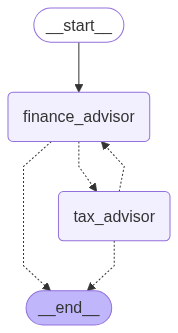

In [13]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
from langchain_core.messages import convert_to_messages


def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
    
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [15]:
from langchain_core.messages import convert_to_messages
from langchain_core.messages import HumanMessage

def evaluate_vs_raw_model(query: str):
    print("🧪 Running MAS (LangGraph) agent...\n")

    mas_response_chunks = []
    for chunk in app.stream({"messages": [("user", query)]}):
        mas_response_chunks.append(chunk)

    # Extract the last assistant message from the final update(s)
    final_messages = []
    for update in mas_response_chunks:
        for node_update in update.values():
            messages = convert_to_messages(node_update["messages"])
            for m in messages:
                if m.type == "ai":  # Capture AI assistant responses
                    final_messages.append(m.content)

    mas_output = "\n".join(final_messages)

    print("\nMAS Agent Response:")
    print(mas_output)

    print("\n" + "=" * 80 + "\n")
    eval_model = ChatOllama(model="llama3.2")
    print("Running raw llama3.2 model (direct)...\n")
    raw_response = eval_model.invoke([HumanMessage(content=query)])

    print("Direct Model Response:\n")
    print(raw_response.content)
    return mas_output, raw_response.content


In [16]:
def judge_responses(user_query, mas_output, raw_output):
    judge_prompt = f"""
    You are a helpful evaluator. Compare the two responses below to the user question.

    Question:
    {user_query}

    Response from MAS Agent:
    {mas_output}

    Response from Raw Model:
    {raw_output}

    Which one provides clearer, more helpful, and contextually appropriate advice? Reply with "MAS", "Raw", or "Tie", and explain your reasoning.
    """
    judge = ChatOllama(model="llama3.2")
    judgment = judge.invoke([HumanMessage(content=judge_prompt)])
    print("Judge Response:\n")
    print(judgment.content)

mas_output, raw_output = evaluate_vs_raw_model("suggest how to invest money")
judge_responses("suggest how to invest money", mas_output, raw_output)



🧪 Running MAS (LangGraph) agent...


✅ MAS Agent Response:


Tool called 'ask_tax_advisor'

Tax Concerns: Investing always involves some level of risk. It's essential to consider your individual financial situation, goals, and risk tolerance when investing.

Recommended Investment Strategies:

1. **Diversification**: Spread your investments across different asset classes, such as stocks, bonds, real estate, and commodities. This can help minimize risk and maximize returns.
2. **Long-term approach**: Investing is a long-term game. Resist the temptation to try to time the market or make quick profits. Instead, focus on steady, long-term growth.
3. **Dollar-cost averaging**: Invest a fixed amount of money at regular intervals, regardless of the market's performance. This can help reduce volatility and timing risks.
4. **Index funds or ETFs**: These investments track a specific market index, such as the S&P 500. They often have lower fees than actively managed funds and can provide broad d